## 1. Import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load Dataset

In [2]:
data = pd.read_csv("house_prices.csv")
print(data.shape)
data.head()

(2000, 10)


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [3]:
data2 = pd.read_csv("house_prices_2.csv")
print(data2.shape)
data2.head()

(300, 10)


,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


## 3. Preparing and Spliting

In [4]:
# Dataset 1
data = data.drop("Id", axis=1)
data = pd.get_dummies(data, columns=["Location", "Condition", "Garage"])

X = data.drop(["Price",], axis=1)
y = data["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


# Dataset 2
data2 = data2.drop("Id", axis=1)

X2 = data2.drop(["SalePrice",], axis=1)
y2 = data2["SalePrice"]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.4)

## 4. Model Training and Prediction

In [5]:
# Dataset 1
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Dataset
model.fit(X2_train, y2_train)
y2_pred = model.predict(X2_test)

## 5. Evaluation

In [6]:
# Dataset 1
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Dataset 1")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

# Dataset 2
mae = mean_absolute_error(y2_test, y2_pred)
rmse = np.sqrt(mean_squared_error(y2_test, y2_pred))
r2 = r2_score(y2_test, y2_pred)

print("Dataset 2")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

Dataset 1
MAE: 232418.9547047871
RMSE: 270037.0631956799
Dataset 2
MAE: 10134.189260758343
RMSE: 11813.13199329612


## 6. Visualization

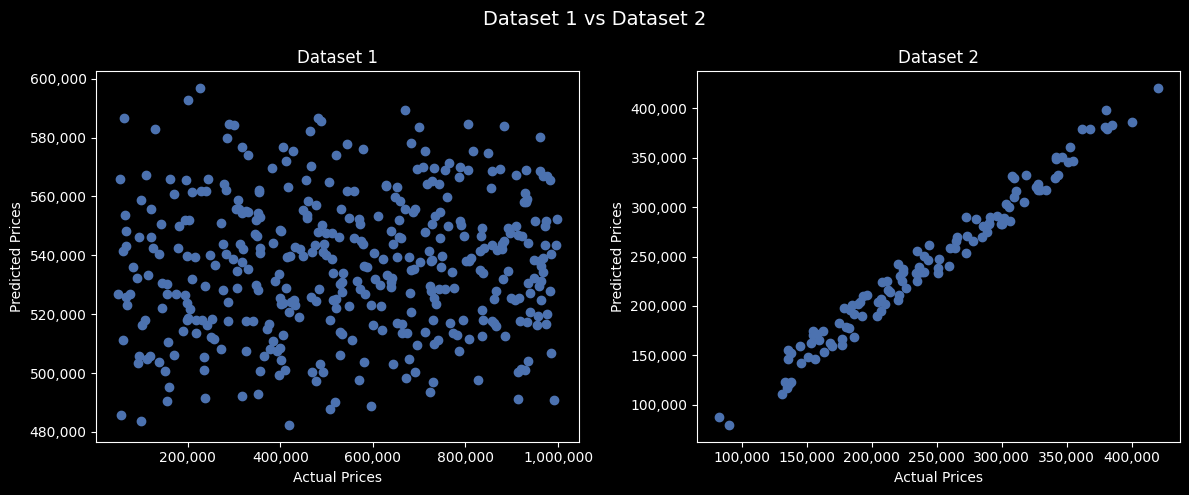

In [7]:
plt.style.use("dark_background")
sns.set_palette("deep")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1
axes[0].scatter(y_test, y_pred)
axes[0].set_title("Dataset 1")
axes[0].set_xlabel("Actual Prices")
axes[0].set_ylabel("Predicted Prices")
axes[0].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
axes[0].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Plot 2
axes[1].scatter(y2_test, y2_pred)
axes[1].set_title("Dataset 2")
axes[1].set_xlabel("Actual Prices")
axes[1].set_ylabel("Predicted Prices")
axes[1].xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.suptitle("Dataset 1 vs Dataset 2", fontsize=14)
plt.tight_layout()
plt.show()

### *Note:-*
#### The first dataset was giving very inconsistent results so I changed the dataset and the results were much more consistent.